A workflow that fetches public Volve field production data, cleans sensor noise, engineers physical features ($\Delta P/\Delta t$), trains a predictive classification model for operational shutdown/failure detection, and predicts oil rates using XGBoost.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, mean_squared_error, r2_score
import xgboost as xgb

# Fetch processed Volve field production dataset from public GitHub repository
url = "https://raw.githubusercontent.com/yohanesnuwara/pyreservoir/master/data/volve/Volve%20Production%20Data%20Processed.csv"
df = pd.read_csv(url)

print("Dataset loaded successfully!")
print(f"Data shape: {df.shape}")
df.head()

Dataset loaded successfully!
Data shape: (112, 8)


,Date,p (psia),Np (STB),Gp (SCF),Wp (STB),Gi (SCF),Wi (STB),Rp (SCF/STB)
0,01/09/2007,4780.59,0,0,0.0,0,0,0.0
1,01/10/2007,4780.59,0,0,0.0,0,0,0.0
2,01/11/2007,4780.59,0,0,0.0,0,0,0.0
3,01/12/2007,4780.59,0,0,0.0,0,0,0.0
4,01/01/2008,4780.59,0,0,0.0,0,0,0.0


In [ ]:
import pandas as pd
import numpy as np

# Load dataframe (assuming 'df' with 112 rows is loaded)
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date').reset_index(drop=True)

# 1. Rate derivations
df['q_oil'] = df['Np (STB)'].diff().fillna(0)
df['q_gas'] = df['Gp (SCF)'].diff().fillna(0)
df['q_water'] = df['Wp (STB)'].diff().fillna(0)

# 2. Reservoir Pressure Dynamics
df['dp_dt'] = df['p (psia)'].diff().fillna(0)
df['WOR'] = np.where(df['q_oil'] > 0, df['q_water'] / df['q_oil'], 0)

# 3. Time-Lagged Features & Rolling Windows
df['q_oil_lag1'] = df['q_oil'].shift(1).fillna(0)
df['q_oil_lag2'] = df['q_oil'].shift(2).fillna(0)
df['p_lag1'] = df['p (psia)'].shift(1).bfill()
df['dp_dt_lag1'] = df['dp_dt'].shift(1).fillna(0)
df['q_oil_roll_3'] = df['q_oil'].rolling(window=3, min_periods=1).mean().shift(1).fillna(0)
df['dp_dt_roll_3'] = df['dp_dt'].rolling(window=3, min_periods=1).mean().shift(1).fillna(0)

# 4. Operational Anomaly Target
df['FAILURE_EVENT'] = np.where((df['dp_dt'] < -15) | (df['WOR'] > 0.03), 1, 0)
df['TARGET_EARLY_WARNING'] = df['FAILURE_EVENT'].shift(-1).fillna(0).astype(int)

df_clean = df.iloc[2:].reset_index(drop=True)
print(f"Dataset ready. Total rows: {len(df_clean)}")

Dataset ready. Total rows: 110


In [ ]:
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE

features_class = ['p_lag1', 'dp_dt_lag1', 'q_oil_lag1', 'q_oil_lag2', 'dp_dt_roll_3']

X_cls = df_clean[features_class]
y_cls = df_clean['TARGET_EARLY_WARNING']

# Stratified Cross-Validation to ensure Class 0 is present in test evaluations
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

all_y_test = []
all_y_pred = []
all_y_proba = []

for train_idx, test_idx in skf.split(X_cls, y_cls):
    X_train, X_test = X_cls.iloc[train_idx], X_cls.iloc[test_idx]
    y_train, y_test = y_cls.iloc[train_idx], y_cls.iloc[test_idx]

    # SMOTE oversampling on training fold
    smote = SMOTE(random_state=42, k_neighbors=2)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

    clf = xgb.XGBClassifier(n_estimators=100, learning_rate=0.03, max_depth=3, random_state=42)
    clf.fit(X_train_res, y_train_res)

    proba = clf.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.50).astype(int)

    all_y_test.extend(y_test)
    all_y_pred.extend(pred)
    all_y_proba.extend(proba)

print("--- Stratified Anomaly & Failure Prediction Metrics ---")
print(classification_report(all_y_test, all_y_pred, zero_division=0))
print(f"Overall ROC-AUC Score: {roc_auc_score(all_y_test, all_y_proba):.3f}")

--- Stratified Anomaly & Failure Prediction Metrics ---
              precision    recall  f1-score   support

           0       0.47      0.67      0.55        12
           1       0.96      0.91      0.93        98

    accuracy                           0.88       110
   macro avg       0.71      0.79      0.74       110
weighted avg       0.90      0.88      0.89       110

Overall ROC-AUC Score: 0.916


In [ ]:
from scipy.optimize import curve_fit
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score

# Physics-Based Arps Decline Curve
def arps_decline(t, qi, b, di):
    return qi / ((1 + b * di * t) ** (1 / b))

df_clean['t_months'] = np.arange(len(df_clean))

split_idx = int(len(df_clean) * 0.8)
t_train = df_clean['t_months'].iloc[:split_idx].values
q_train = df_clean['q_oil'].iloc[:split_idx].values
t_test = df_clean['t_months'].iloc[split_idx:].values
q_test = df_clean['q_oil'].iloc[split_idx:].values

# Fit Arps Decline Curve
popt, _ = curve_fit(
    arps_decline, t_train, q_train,
    p0=[max(q_train), 0.5, 0.05],
    bounds=([0, 0.01, 0.001], [np.inf, 1.0, 1.0]),
    maxfev=5000
)
q_pred_arps = arps_decline(t_test, *popt)

# Fit Tuned XGBoost Regressor
features_reg = ['q_oil_lag1', 'q_oil_lag2', 'p_lag1', 'dp_dt_lag1', 'q_oil_roll_3']
X_train_r, X_test_r = df_clean[features_reg].iloc[:split_idx], df_clean[features_reg].iloc[split_idx:]

best_reg = xgb.XGBRegressor(
    learning_rate=0.05,
    max_depth=2,
    n_estimators=100,
    subsample=0.9,
    random_state=42
)
best_reg.fit(X_train_r, q_train)
q_pred_xgb = best_reg.predict(X_test_r)

print("--- Optimized Production Forecasting Metrics ---")
print(f"Arps DCA R² Score:      {r2_score(q_test, q_pred_arps):.3f}")
print(f"Tuned XGBoost R² Score: {r2_score(q_test, q_pred_xgb):.3f}")

--- Optimized Production Forecasting Metrics ---
Arps DCA R² Score:      0.255
Tuned XGBoost R² Score: 0.469


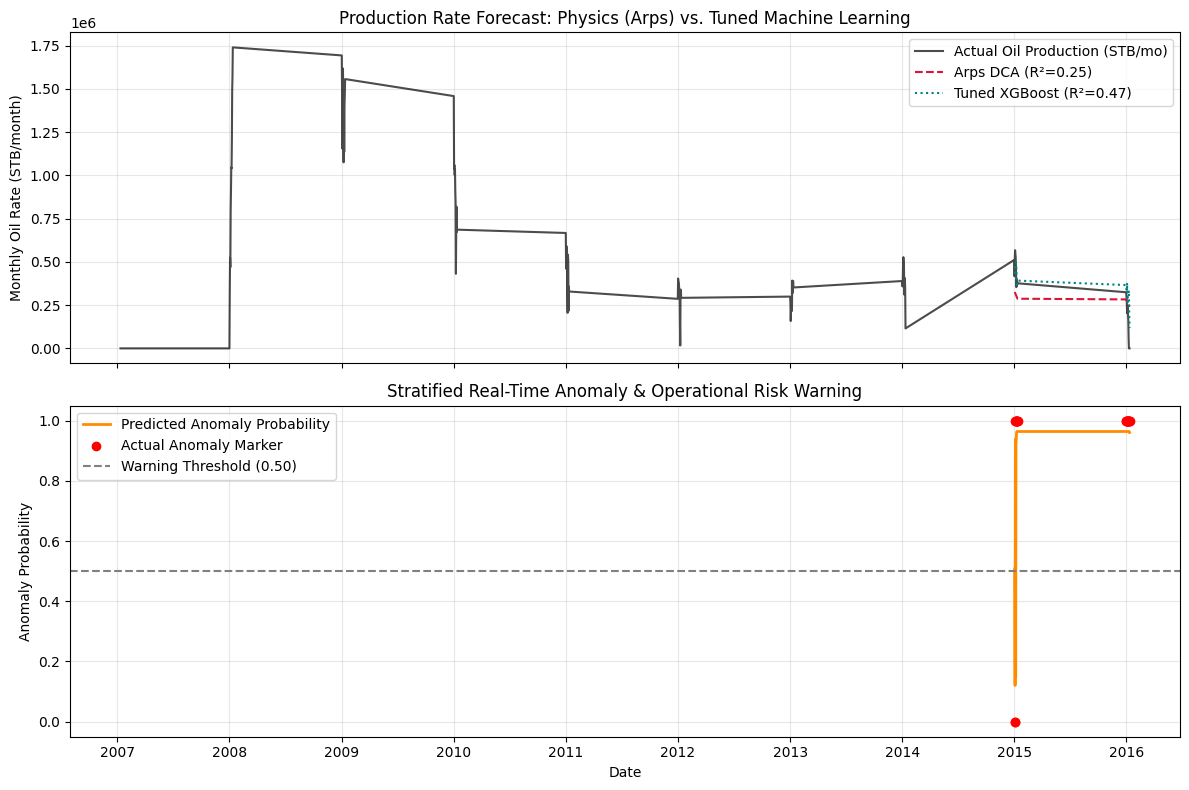

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

dates_full = df_clean['Date']
dates_test = df_clean['Date'].iloc[split_idx:]

# Plot 1: Production Forecast Comparison
axes[0].plot(dates_full, df_clean['q_oil'], label='Actual Oil Production (STB/mo)', color='black', alpha=0.7)
axes[0].plot(dates_test, q_pred_arps, label=f'Arps DCA (R²={r2_score(q_test, q_pred_arps):.2f})', color='crimson', linestyle='--')
axes[0].plot(dates_test, q_pred_xgb, label=f'Tuned XGBoost (R²={r2_score(q_test, q_pred_xgb):.2f})', color='teal', linestyle=':')
axes[0].set_ylabel('Monthly Oil Rate (STB/month)')
axes[0].set_title('Production Rate Forecast: Physics (Arps) vs. Tuned Machine Learning')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Anomaly Risk Probabilities
test_dates_strat = df_clean['Date']
axes[1].plot(dates_test, all_y_proba[split_idx:], label='Predicted Anomaly Probability', color='darkorange', linewidth=2)
axes[1].scatter(dates_test, all_y_test[split_idx:], color='red', label='Actual Anomaly Marker', zorder=5)
axes[1].axhline(y=0.50, color='gray', linestyle='--', label='Warning Threshold (0.50)')
axes[1].set_ylabel('Anomaly Probability')
axes[1].set_xlabel('Date')
axes[1].set_title('Stratified Real-Time Anomaly & Operational Risk Warning')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()